In [56]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer # For converting the word into a vector 
from sklearn.naive_bayes import MultinomialNB # For multinomail Naive Nayes Classification

from sklearn.metrics import confusion_matrix,classification_report

In [ ]:
df = pd.read_csv('datasets\spam.csv',encoding='latin') # The encoding was in latin

In [15]:
df.shape

(5572, 5)

In [16]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [ ]:
df.columns # As you can see there are columns which are empty so we are gonna drop them , and also rename the other two columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

In [22]:
df = df.drop(columns=[ 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'])

In [23]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df.columns = [
    "label",
    "message"
]
# Use this or the rename operator ; as there are only two cols this was less hectic and simple but in a dataset with many columns 
# strictly use the rename operator to avoid conflicts and precision.

In [ ]:
df.head() 

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df.nunique() # A quick check to see whether there is a third label type or is it spam and ham only 

label         2
message    5169
dtype: int64

In [31]:
df.isna().sum() # To make sure there are no null values present

label      0
message    0
dtype: int64

In [32]:
df.label.value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [33]:
# As you can see that the column data containing ham and spam is imbalanced so we need to take this into account when splitting
# and building the model.

In [34]:
# So now we will split the dataset using stratified y values 
# WHAT THIS DOES ? - Basically makes sure that the split dataset dont contain all the ham in one split and spam in other ,
# which is possible considering the counts of ham and spam

In [36]:
X_train ,X_test , y_train , y_test = train_test_split(
                                                        df['message'], # X
                                                        df['label'], # y
                                                        test_size=0.3,
                                                        stratify=df['label'],
                                                        random_state=42
)

In [41]:
# Now lets use the column Vectorizer to convert the train split into vectors.
# Why didn't we do this earlier ? To avoide Data Leakage to the model

vectorizer = CountVectorizer()

In [ ]:
vectorizer.fit(X_train) 
# Fit seperately to avoid leakage and then transform on both so that test split only gets transformed and vectorizer never learns test set values.

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"stop_words stop_words: {'english'}, list, default=NoneIf 'english', a built-in stop word list for English is used.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None
,"token_pattern token_pattern: str or None, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp select tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentword n-grams or char n-grams to be extracted. All values of n suchsuch that min_n <= n <= max_n will be used. For example an``ngram_range`` of ``(1, 1)`` means only unigrams, ``(1, 2)`` meansunigrams and bigrams, and ``(2, 2)`` means only bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word n-gram or charactern-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21Since v0.21, if ``input`` is ``filename`` or ``file``, the data isfirst read from the file and then passed to the given callableanalyzer.",'word'


In [44]:
X_train_vectorized = vectorizer.transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

In [45]:
# Instantiating MultinomialNB model
model = MultinomialNB(
                        fit_prior=False # How it works: It forces the model to treat spam and ham as equally likely (\(P(c) = 0.5\)).
)

In [47]:
model.fit(X_train_vectorized,y_train) # fit the model with appropriate model parameters

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",False
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [48]:
# Now to make sure we vectorize any input from the user we will make a custom function to accept user input using a tuple
def spam_or_ham(text):
    vectorized_text = vectorizer.transform([text])
    prediction = model.predict(vectorized_text)[0] # Predicts the first element in case there are many elements in the tuple
    return "SPAM" if prediction == 1 else "HAM"

In [55]:
print(spam_or_ham("baseball tickets later tonight"))      # HAM

HAM


In [57]:
y_pred = model.predict(X_test_vectorized)

In [60]:
print(classification_report(y_test,y_pred)) # Really good results but let's check the confusion matrix to actuall get to know what's happening

              precision    recall  f1-score   support

         ham       0.99      0.99      0.99      1448
        spam       0.92      0.94      0.93       224

    accuracy                           0.98      1672
   macro avg       0.96      0.96      0.96      1672
weighted avg       0.98      0.98      0.98      1672



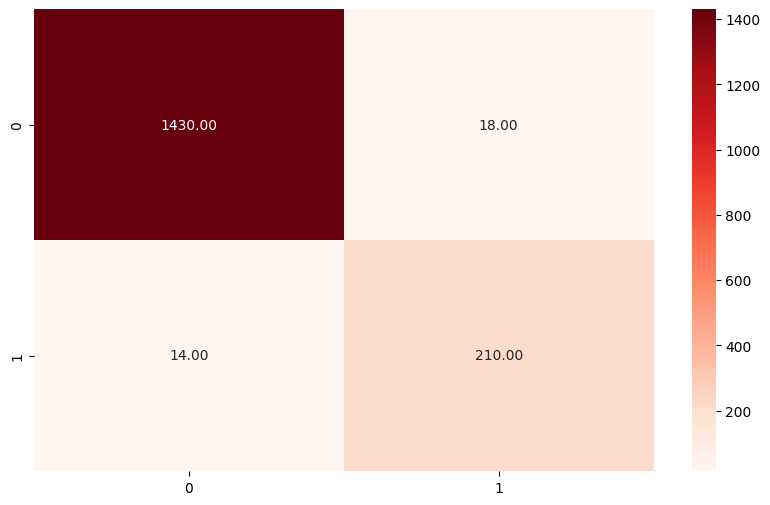

In [75]:
plt.figure(figsize=(10,6))
sns.heatmap(
                data = confusion_matrix(y_test,y_pred),
                annot=True,
                fmt=".2f",
                cmap = "Reds"
)
plt.show()

In [76]:
# A pretty good model I guess